In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix,recall_score, precision_score, classification_report, ConfusionMatrixDisplay

In [60]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
data = pd.read_csv('/content/drive/MyDrive/B-CODECRUNCH/spotify_songs.csv')

In [62]:
data.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [63]:
data.info() #print(data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

<Axes: xlabel='instrumentalness', ylabel='loudness'>

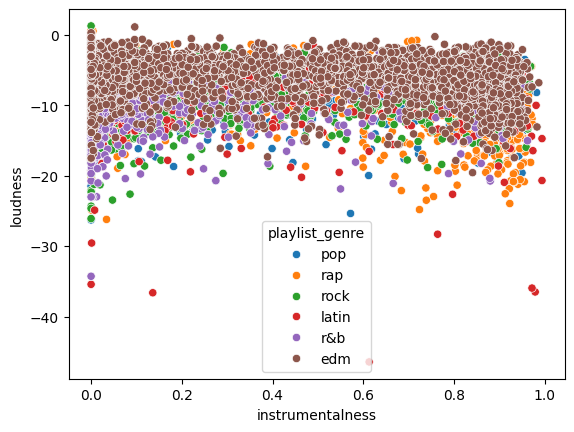

In [64]:
sns.scatterplot(data, x="instrumentalness", y="loudness",hue="playlist_genre")

In [65]:
X = data[["instrumentalness", "loudness","acousticness","energy"]]
y = data["playlist_genre"]

In [66]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,test_size=0.2)

In [67]:
Xtrain #print(Xtrain)

,instrumentalness,loudness,acousticness,energy
23492,0.008160,-7.434,0.137000,0.892
30947,0.000000,-4.079,0.017500,0.737
15251,0.002040,-4.134,0.169000,0.588
13717,0.000112,-8.519,0.000291,0.728
15662,0.017300,-8.760,0.014600,0.953
...,...,...,...,...
5371,0.094100,-12.811,0.978000,0.394
19189,0.000264,-6.471,0.028200,0.852
12216,0.000000,-6.012,0.620000,0.591
27957,0.926000,-7.809,0.004300,0.845


In [68]:
SpotClassifier = KNeighborsClassifier(n_neighbors=5,metric="euclidean")

In [69]:
SpotClassifier.fit(Xtrain,ytrain)

KNeighborsClassifier(metric='euclidean')

In [70]:
ypred = SpotClassifier.predict(Xtest)

In [71]:
accuracy_score(ytest,ypred)

0.31201461854728185

In [72]:
recall_score(ytest,ypred,average="weighted")

0.31201461854728185

In [73]:
precision_score(ytest,ypred,average="weighted")

0.3092828339575956

In [74]:
f1_score(ytest,ypred,average="weighted")

0.3072239995373781

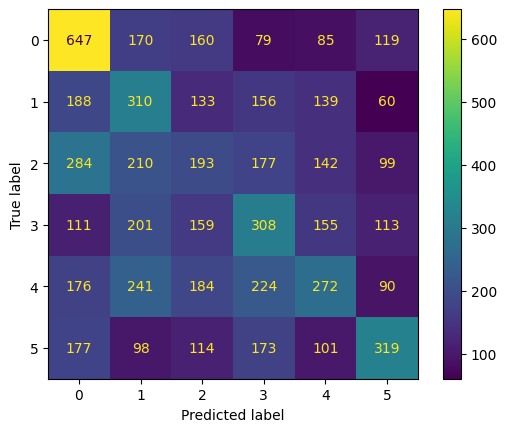

In [75]:
cm = confusion_matrix(ytest,ypred)
display = ConfusionMatrixDisplay(cm)
display.plot()